<a href="https://colab.research.google.com/github/Fahadqureshi0/Dog-vs-Cat-Classification-using-CNNs/blob/main/Dog_vs_Cat_Classification_Transfer_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Extracting Data using Kaggle API**

In [1]:
# Installing Kaggle
!pip install -q -U kaggle

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.2/126.2 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 262.5/262.5 kB 19.1 MB/s eta 0:00:00


In [2]:
# Loading Kaggle API Token
from google.colab import userdata
import os

token = userdata.get("KAGGLE_API_TOKEN")

os.environ["KAGGLE_API_TOKEN"] = token

print("Kaggle token loaded:", bool(token))

Kaggle token loaded: True


**Importing Dataset**

In [3]:
# Downloading CAt vs Dog Dataset
!kaggle datasets download -d bhavikjikadara/dog-and-cat-classification-dataset

Dataset URL: https://www.kaggle.com/datasets/bhavikjikadara/dog-and-cat-classification-dataset
License(s): apache-2.0
100% 775M/775M [00:23<00:00, 34.5MB/s]



In [4]:
# Extract Data
!unzip -q dog-and-cat-classification-dataset.zip

In [5]:
# Counting files
import os

cat_path = '/content/PetImages/Cat'
dog_path = '/content/PetImages/Dog'

cat_count = len(os.listdir(cat_path))
dog_count = len(os.listdir(dog_path))

print("Number of Cat images:", cat_count)
print("Number of Dog images:", dog_count)
print("Total images:", cat_count + dog_count)

Number of Cat images: 12499
Number of Dog images: 12499
Total images: 24998


In [6]:
# Printing name of Images
files_name = os.listdir('/content/PetImages/Cat')
print(files_name)

['1760.jpg', '10051.jpg', '7241.jpg', '4584.jpg', '6266.jpg', '1895.jpg', '1201.jpg', '8485.jpg', '402.jpg', '9270.jpg', '562.jpg', '3046.jpg', '8599.jpg', '1224.jpg', '4120.jpg', '4670.jpg', '9691.jpg', '63.jpg', '965.jpg', '1639.jpg', '9622.jpg', '12125.jpg', '3377.jpg', '3750.jpg', '9058.jpg', '2514.jpg', '5827.jpg', '1935.jpg', '7768.jpg', '2592.jpg', '5810.jpg', '185.jpg', '10929.jpg', '5702.jpg', '7840.jpg', '2086.jpg', '8769.jpg', '4043.jpg', '8142.jpg', '2439.jpg', '2454.jpg', '4576.jpg', '2827.jpg', '4335.jpg', '2828.jpg', '5595.jpg', '12152.jpg', '6874.jpg', '7090.jpg', '9488.jpg', '1460.jpg', '5739.jpg', '5555.jpg', '9635.jpg', '6472.jpg', '3102.jpg', '1897.jpg', '4480.jpg', '284.jpg', '9868.jpg', '3676.jpg', '8803.jpg', '6115.jpg', '7653.jpg', '3128.jpg', '11040.jpg', '10428.jpg', '6206.jpg', '4150.jpg', '10600.jpg', '10749.jpg', '5048.jpg', '2655.jpg', '4134.jpg', '9415.jpg', '6213.jpg', '8313.jpg', '12373.jpg', '7422.jpg', '6631.jpg', '6780.jpg', '5940.jpg', '684.jpg', '1

In [7]:
# Printing name of Images
files_name = os.listdir('/content/PetImages/Dog')
print(files_name)

['1760.jpg', '10051.jpg', '7241.jpg', '4584.jpg', '6266.jpg', '1895.jpg', '1201.jpg', '8485.jpg', '402.jpg', '9270.jpg', '562.jpg', '3046.jpg', '8599.jpg', '1224.jpg', '4120.jpg', '4670.jpg', '9691.jpg', '63.jpg', '965.jpg', '1639.jpg', '9622.jpg', '12125.jpg', '3377.jpg', '3750.jpg', '9058.jpg', '2514.jpg', '5827.jpg', '1935.jpg', '7768.jpg', '2592.jpg', '5810.jpg', '185.jpg', '10929.jpg', '5702.jpg', '7840.jpg', '2086.jpg', '8769.jpg', '4043.jpg', '8142.jpg', '2439.jpg', '2454.jpg', '4576.jpg', '2827.jpg', '4335.jpg', '2828.jpg', '5595.jpg', '12152.jpg', '6874.jpg', '7090.jpg', '9488.jpg', '1460.jpg', '5739.jpg', '5555.jpg', '9635.jpg', '6472.jpg', '3102.jpg', '1897.jpg', '4480.jpg', '284.jpg', '9868.jpg', '3676.jpg', '8803.jpg', '6115.jpg', '7653.jpg', '3128.jpg', '11040.jpg', '10428.jpg', '6206.jpg', '4150.jpg', '10600.jpg', '10749.jpg', '5048.jpg', '2655.jpg', '4134.jpg', '9415.jpg', '6213.jpg', '8313.jpg', '12373.jpg', '7422.jpg', '6631.jpg', '6780.jpg', '5940.jpg', '684.jpg', '1

**Importing Dependencies**

In [11]:
# Data Manipulation
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
!pip install -q opencv-python
# Data Preprocessing
from sklearn.model_selection import train_test_split
import cv2
from google.colab.patches import cv2_imshow


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.8/73.8 MB 18.9 MB/s eta 0:00:00


**Displaying Images**

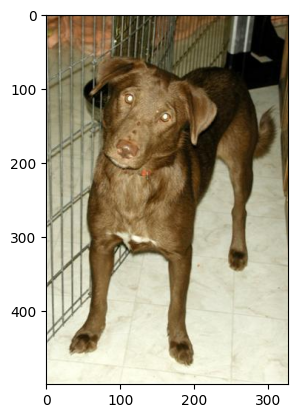

In [12]:
# Displaying Dog Image
img = mpimg.imread('/content/PetImages/Dog/1.jpg')
imgplt = plt.imshow(img)
plt.show()

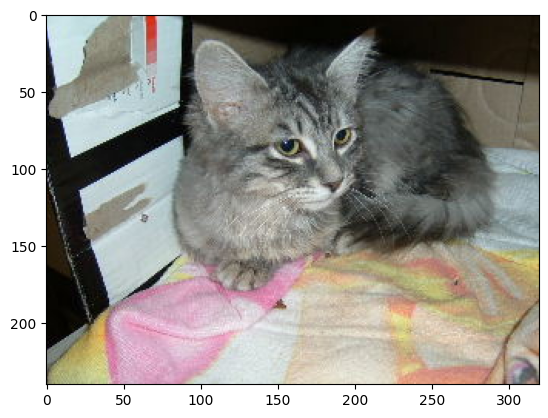

In [13]:
# Displaying Cat Image
img = mpimg.imread('/content/PetImages/Cat/4823.jpg')
imgplt = plt.imshow(img)

plt.show()

In [14]:
import os

cat_files = os.listdir('/content/PetImages/Cat/')
dog_files = os.listdir('/content/PetImages/Dog/')

print("Cats:")
for i in range(5):
    name = os.path.splitext(cat_files[i])[0]
    print("cat_" + name)

print("\nDogs:")
for i in range(5):
    name = os.path.splitext(dog_files[i])[0]
    print("dog_" + name)

Cats:
cat_1760
cat_10051
cat_7241
cat_4584
cat_6266

Dogs:
dog_1760
dog_10051
dog_7241
dog_4584
dog_6266


In [15]:
import os

cat_files = os.listdir('/content/PetImages/Cat/')
dog_files = os.listdir('/content/PetImages/Dog/')

cat_count = 0
dog_count = 0

for img_file in cat_files:
    cat_count += 1

for img_file in dog_files:
    dog_count += 1

print("Number of Dog images:", dog_count)
print("Number of Cat images:", cat_count)

Number of Dog images: 12499
Number of Cat images: 12499


**Resizzing All Images Data**

In [16]:
 # Creating Directory for Resizzed Images
os.mkdir('/content/image resized')

In [17]:
import os
from PIL import Image

original_folder = '/content/PetImages'
resized_folder = '/content/image_resized'

for category in ['Cat', 'Dog']:
    category_path = os.path.join(original_folder, category)
    new_category_folder = os.path.join(resized_folder, category)
    os.makedirs(new_category_folder, exist_ok=True)

    for filename in os.listdir(category_path)[:2000]:
        img_path = os.path.join(category_path, filename)

        img = Image.open(img_path)
        img = img.resize((224, 224))
        img = img.convert('RGB')

        img.save(os.path.join(new_category_folder, filename))

print("Images resized successfully!")

Images resized successfully!


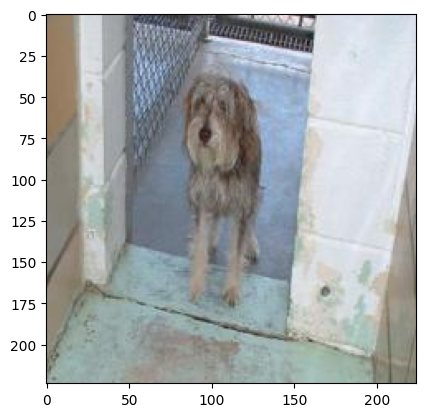

In [20]:
# Displaying Resized Image
img = mpimg.imread('/content/image_resized/Dog/10009.jpg')
imgplt = plt.imshow(img)
plt.show()

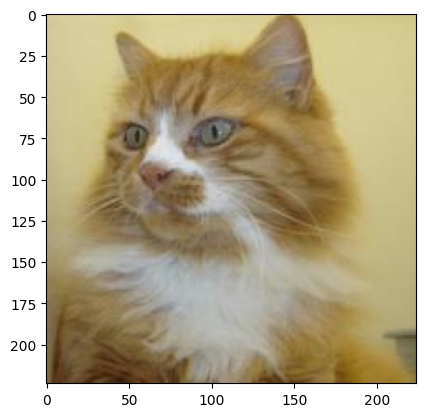

In [22]:
# Displaying Resized Image
img = mpimg.imread('/content/image_resized/Cat/10009.jpg')
imgplt = plt.imshow(img)
plt.show()

**Creating Labels for Resized Images**

In [23]:
# Cat ---> 0
# Dog ---> 1

In [24]:
import os

labels = []

for category in ['Cat', 'Dog']:
    files = os.listdir('/content/image_resized/' + category)

    for filename in files[:2000]:
        if category == 'Dog':
            labels.append(1)
        else:
            labels.append(0)

print("Total labels:", len(labels))

Total labels: 4000


In [25]:
print(category, filename[0:5])
print(len(labels))

Dog 11332
4000


In [26]:
# Counting Images of Dogs and Cats out of 4000 images
values, counts = np.unique(labels, return_counts=True)
print(values, counts)

[0 1] [2000 2000]


**Converting all the resized images to numpy arrays**

In [27]:
import glob
import cv2
import numpy as np

cat_files = glob.glob('/content/image_resized/Cat/*.jpg')
dog_files = glob.glob('/content/image_resized/Dog/*.jpg')

files = cat_files + dog_files

print("Cat images:", len(cat_files))
print("Dog images:", len(dog_files))
print("Total images:", len(files))

dog_cat_images = np.asarray([cv2.imread(file) for file in files])

print("Images shape:", dog_cat_images.shape)

Cat images: 2000
Dog images: 2000
Total images: 4000
Images shape: (4000, 224, 224, 3)


In [28]:
print(dog_cat_images)

[[[[198 189 155]
   [200 191 157]
   [188 182 147]
   ...
   [103 109 104]
   [ 79  85  80]
   [ 55  61  56]]

  [[203 194 160]
   [205 199 164]
   [195 189 154]
   ...
   [ 83  89  84]
   [ 66  72  67]
   [ 62  68  63]]

  [[199 193 158]
   [203 199 164]
   [193 189 154]
   ...
   [ 89  96  89]
   [ 74  81  74]
   [ 64  71  64]]

  ...

  [[ 69  58  84]
   [ 74  63  89]
   [ 71  59  87]
   ...
   [134 108 132]
   [135 108 134]
   [126  99 125]]

  [[ 55  44  70]
   [ 60  49  75]
   [ 61  49  77]
   ...
   [165 139 163]
   [155 128 154]
   [148 121 147]]

  [[ 56  45  71]
   [ 51  40  66]
   [ 49  37  65]
   ...
   [200 174 197]
   [193 166 192]
   [209 182 208]]]


 [[[ 12  17  16]
   [ 11  16  15]
   [ 10  15  14]
   ...
   [ 84  84  72]
   [ 83  83  69]
   [ 82  82  68]]

  [[ 10  15  14]
   [ 10  15  14]
   [  9  14  13]
   ...
   [ 78  77  63]
   [ 78  77  63]
   [ 78  78  62]]

  [[ 10  12  12]
   [ 10  12  12]
   [ 11  13  13]
   ...
   [ 71  68  53]
   [ 73  70  55]
   [ 75  73

In [29]:
type(dog_cat_images)

numpy.ndarray

In [30]:
X = dog_cat_images
Y = np.asarray(labels)

**Train Test Split**

In [31]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

In [32]:
print(X.shape, X_train.shape,X_test.shape)

(4000, 224, 224, 3) (3200, 224, 224, 3) (800, 224, 224, 3)


# 3200 Training Imges
# 800 Testing Images

In [33]:
# Scailing Data
X_train_scale = X_train/255
X_test_scale = X_test/255

In [34]:
print(X_train_scale)

[[[[0.18039216 0.18039216 0.18039216]
   [0.15294118 0.15294118 0.15294118]
   [0.12941176 0.12941176 0.12941176]
   ...
   [0.         0.01960784 0.01568627]
   [0.01568627 0.03529412 0.03137255]
   [0.03529412 0.05490196 0.05098039]]

  [[0.17254902 0.17254902 0.17254902]
   [0.14901961 0.14901961 0.14901961]
   [0.12156863 0.12156863 0.12156863]
   ...
   [0.01568627 0.03529412 0.03137255]
   [0.02352941 0.04313725 0.03921569]
   [0.03921569 0.05882353 0.05490196]]

  [[0.16470588 0.16470588 0.16470588]
   [0.14117647 0.14117647 0.14117647]
   [0.11372549 0.11372549 0.11372549]
   ...
   [0.04313725 0.0627451  0.05882353]
   [0.03921569 0.05882353 0.05490196]
   [0.04313725 0.0627451  0.05882353]]

  ...

  [[0.19215686 0.20784314 0.30588235]
   [0.19215686 0.21568627 0.30588235]
   [0.19607843 0.21960784 0.30980392]
   ...
   [0.32941176 0.3372549  0.54901961]
   [0.24313725 0.22352941 0.49411765]
   [0.21960784 0.18039216 0.47843137]]

  [[0.18039216 0.18431373 0.28627451]
   [0.1

In [35]:
print(X_test_scale)

[[[[0.34509804 0.45098039 0.62352941]
   [0.34509804 0.45098039 0.62352941]
   [0.34117647 0.44313725 0.62352941]
   ...
   [0.34509804 0.38039216 0.51372549]
   [0.34901961 0.38431373 0.51764706]
   [0.35686275 0.39215686 0.5254902 ]]

  [[0.25882353 0.35686275 0.51372549]
   [0.2627451  0.36078431 0.51764706]
   [0.27058824 0.36862745 0.5254902 ]
   ...
   [0.35686275 0.39215686 0.5254902 ]
   [0.34901961 0.38431373 0.51764706]
   [0.34509804 0.38039216 0.51372549]]

  [[0.17254902 0.25490196 0.37647059]
   [0.17647059 0.25882353 0.38039216]
   [0.18039216 0.2627451  0.38431373]
   ...
   [0.38823529 0.42352941 0.55686275]
   [0.38431373 0.41960784 0.55294118]
   [0.38039216 0.41568627 0.54901961]]

  ...

  [[0.63921569 0.66666667 0.77254902]
   [0.64705882 0.6745098  0.78039216]
   [0.64313725 0.67058824 0.77647059]
   ...
   [0.11372549 0.12156863 0.1254902 ]
   [0.14901961 0.15686275 0.16078431]
   [0.19607843 0.20392157 0.20784314]]

  [[0.6        0.62745098 0.73333333]
   [0.6

**Building Neural Network**

In [45]:
!pip install -q tensorflow
import tensorflow as tf

In [47]:
import tensorflow as tf

pretrained_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

pretrained_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [48]:
num_of_classes = 2

model = tf.keras.Sequential([
    pretrained_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(num_of_classes, activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │         2,562 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,260,546 (8.62 MB)

 Trainable params: 2,562 (10.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [49]:
# Compiling Model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['acc']
)

In [52]:
model.fit(X_train_scale, Y_train, epochs=5)

Epoch 1/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 55s 551ms/step - acc: 0.9919 - loss: 0.0304
Epoch 2/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 55s 550ms/step - acc: 0.9944 - loss: 0.0265
Epoch 3/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 55s 552ms/step - acc: 0.9956 - loss: 0.0222
Epoch 4/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 55s 549ms/step - acc: 0.9953 - loss: 0.0201
Epoch 5/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 55s 553ms/step - acc: 0.9966 - loss: 0.0179


In [53]:
score , acc = model.evaluate(X_test_scale, Y_test)
print("Test Loss = ",score )
print("Test Accuracy = ", acc)

25/25 ━━━━━━━━━━━━━━━━━━━━ 15s 555ms/step - acc: 0.9750 - loss: 0.0603
Test Loss =  0.060250166803598404
Test Accuracy =  0.9750000238418579


**Predictive System**

Path of Image to be Predicted: /content/Cat_image.jpg


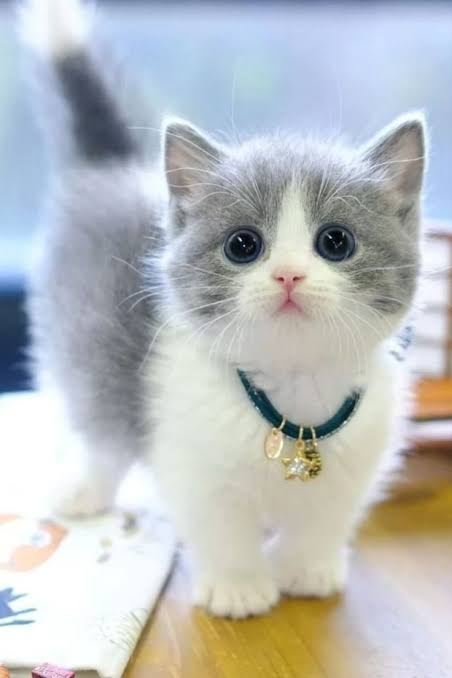

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
[[9.9987900e-01 1.2100635e-04]]
0
The image is a Cat


In [57]:
input_image_path = input("Path of Image to be Predicted: ")

input_image = cv2.imread(input_image_path)

cv2_imshow(input_image)

input_image_resize = cv2.resize(input_image, (224, 224))

input_image_scaled = input_image_resize/225

image_reshape = np.reshape(input_image_scaled, [1,224,224,3])

input_prediction = model.predict(image_reshape)
print(input_prediction)

input_predict_label = np.argmax(input_prediction)
print(input_predict_label)


if input_predict_label == 0:
  print("The image is a Cat")
else:
  print("The image is a Dog")

**Predicting For (Dog)**

Path of Image to be Predicted: /content/Dog_image.jpg


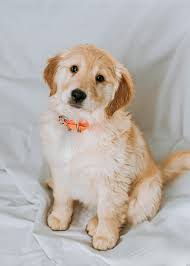

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
[[3.0723633e-05 9.9996924e-01]]
1
The image is a Dog


In [58]:
input_image_path = input("Path of Image to be Predicted: ")

input_image = cv2.imread(input_image_path)

cv2_imshow(input_image)

input_image_resize = cv2.resize(input_image, (224, 224))

input_image_scaled = input_image_resize/225

image_reshape = np.reshape(input_image_scaled, [1,224,224,3])

input_prediction = model.predict(image_reshape)
print(input_prediction)

input_predict_label = np.argmax(input_prediction)
print(input_predict_label)


if input_predict_label == 0:
  print("The image is a Cat")
else:
  print("The image is a Dog")